## Setup Environment

In [ ]:
!pip uninstall -y transformers peft torchao -q

!pip install -q \
transformers==4.55.0 \
peft==0.17.1 \
accelerate \
bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
# Mount Google Drive to access datasets and save models
from google.colab import drive
drive.mount('/content/drive')

# Define the base Google Drive path for artifacts
DRIVE_BASE_PATH = '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from datasets import load_from_disk

train_dataset = load_from_disk(
    "/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/tokenized_train"
)

valid_dataset = load_from_disk(
    "/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/tokenized_valid"
)

print(train_dataset)
print(train_dataset.column_names)

sample = train_dataset[0]

print(sample.keys())
print("input_ids length:", len(sample["input_ids"]))
print("attention_mask length:", len(sample["attention_mask"]))
print("labels length:", len(sample["labels"]))

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 3121
})
['input_ids', 'attention_mask', 'labels']
dict_keys(['input_ids', 'attention_mask', 'labels'])
input_ids length: 256
attention_mask length: 256
labels length: 256


## Load Tokenized Datasets and Base Model

# **Notebook 6: Fine-Tuning Pipeline**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED:**
- [ ] `./tokenized_train/` + `./tokenized_valid/` — Created by Notebook 2
- [ ] GPU runtime enabled (T4 minimum)

**Files this notebook will CREATE:**
- [ ] `./intent_lora_best/` — Best LoRA checkpoint (by val loss) _(Required by NB7)_
- [ ] `./intent_lora/` — Final LoRA checkpoint _(Backup)_
- [ ] `training_log.csv` + `training_curves.png` — Evidence for report

---

## **Stage 4: Solution V2 (Fine-Tuned Retrieval-Assisted Generation)**

### **Task 4.1: Configure Fine-Tuning Pipeline**

#### **4.1.1 Configure PEFT Framework [3 marks]**
**The Task:** Apply LoRA (or QLoRA) to the model's `q_proj` and `v_proj` attention modules, set adapter settings and target modules, and prepare the training environment.

**Hints & Tips:**
* LoRA adds small trainable matrices to frozen attention layers — only ~0.5–1% of params update.
* `r=16` = rank of the low-rank matrices; `lora_alpha=32` scales them (rule of thumb: alpha = 2×r).
* `target_modules=["q_proj","v_proj"]`. Adding `["k_proj","o_proj"]` trains more params but may overfit on small data.
* Call `peft_model.print_trainable_parameters()` to confirm the tiny trainable %.

**LoRA Config Tuning:**
* `r`: 8 (lighter), **16 (recommended)**, 32 (more capacity).
* `lora_alpha`: usually 2×r → 16, **32**, 64.

**Learner Inference:** Updating only attention projections fundamentally changes behaviour (chat → JSON) using a fraction of the compute.

In [ ]:


import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

# -----------------------------
# Model
# -----------------------------
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

# -----------------------------
# Tokenizer
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# -----------------------------
# Base Model
# -----------------------------
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

# -----------------------------
# LoRA Configuration
# -----------------------------
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj",
        "v_proj"
    ]
)

# -----------------------------
# Apply LoRA
# -----------------------------
peft_model = get_peft_model(base_model, lora_config)

print("\nTrainable Parameters:")
peft_model.print_trainable_parameters()


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



Trainable Parameters:
trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


#### **4.1.2 Configure Training Parameters [2 marks]**
**The Task:** Define the learning rate, batch size, number of steps/epochs, optimisation strategy (AdamW), and quantisation settings.

**Hints & Tips:**
* Initialise `AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=2e-4)`.
* Build `DataLoader`s for the train and validation sets (remember `set_format("torch", ...)` after `load_from_disk`).
* Define `VAL_EVERY` (e.g. 10 steps) and an early-stopping `PATIENCE` (e.g. 3) for the next task.

**Parameter Tuning:**
* `lr=2e-4` standard; try `1e-4` (slower) or `5e-4` (faster).
* `batch_size=4` fits T4; use 2 if OOM, 8 on A100.
* `max_steps=200`: ~25% of one epoch on 3200 rows. Increase to 400–500 for a full epoch.

**Learner Inference:** These hyperparameters control how fast and how stably the adapter learns the JSON-extraction task.

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader

# -----------------------------
# Training Parameters
# -----------------------------
LEARNING_RATE = 2e-4
BATCH_SIZE = 4
MAX_STEPS = 200 # Roughly 25% of one epoch on 3200 rows
VAL_EVERY = 50
PATIENCE = 3 # Early stopping patience

# -----------------------------
# Optimizer
# -----------------------------
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, peft_model.parameters()), lr=LEARNING_RATE)

print(f"Learning Rate: {LEARNING_RATE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Max Steps: {MAX_STEPS}")
print(f"Validation Every: {VAL_EVERY} steps")
print(f"Early Stopping Patience: {PATIENCE}")


Learning Rate: 0.0002
Batch Size: 4
Max Steps: 200
Validation Every: 50 steps
Early Stopping Patience: 3


In [ ]:
# -----------------------------
# DataLoaders
# -----------------------------
# Set dataset format to torch for DataLoader compatibility
train_dataset.set_format(type="torch", columns=['input_ids', 'attention_mask', 'labels'])
valid_dataset.set_format(type="torch", columns=['input_ids', 'attention_mask', 'labels'])

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of validation batches: {len(valid_dataloader)}")


Number of training batches: 781
Number of validation batches: 98


In [ ]:
# YOUR CODE HERE


### **Task 4.2: Train Fine-Tuned Model**

#### **4.2.1 Execute Fine-Tuning [5 marks]**
**The Task:** Run the custom PyTorch training loop. Monitor BOTH train and validation loss at regular intervals, implement early stopping based on validation loss, and plot the train-vs-validation loss curves.

**Hints & Tips:**
* The validation loop runs every `VAL_EVERY` steps under `torch.no_grad()` (no gradients).
* Early stopping: track `best_val_loss`; if it doesn't improve for `PATIENCE` checks, stop.
* The loss-curve plot is mandatory evidence — save it as `training_curves.png`.

**What to look for in the curve:**
* Both lines falling → learning, no overfitting.
* Val rises while train falls → overfitting (early stopping saves you).
* Both flat → LR too low or data too small.
* Val spikes → bad batch / instability.

**Learner Inference:** Falling loss proves gradient descent is teaching the JSON format. Validation monitoring prevents silent memorisation.

In [ ]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
# YOUR CODE HERE
# ==========================================================
# 4.2.1 Execute Fine-Tuning
# ==========================================================

import os
import torch
from tqdm.auto import tqdm

# Save paths
BEST_MODEL_PATH = "/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/intent_lora_best"

os.makedirs(BEST_MODEL_PATH, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
peft_model.to(device)

peft_model.train()

train_losses = []
val_losses = []
training_log = []

best_val_loss = float("inf")
patience_counter = 0

global_step = 0

print("="*60)
print("Starting Fine-Tuning...")
print("="*60)

stop_training = False

for epoch in range(10):        # large value, early stopping will stop automatically

    print(f"\nEpoch {epoch+1}")

    for batch in tqdm(train_dataloader):

        global_step += 1

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = peft_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        train_losses.append(loss.item())

        # ----------------------------
        # Validation
        # ----------------------------
        if global_step % VAL_EVERY == 0:

            peft_model.eval()

            val_loss_total = 0

            with torch.no_grad():

                for val_batch in valid_dataloader:

                    val_batch = {k: v.to(device) for k, v in val_batch.items()}

                    outputs = peft_model(
                        input_ids=val_batch["input_ids"],
                        attention_mask=val_batch["attention_mask"],
                        labels=val_batch["labels"]
                    )

                    val_loss_total += outputs.loss.item()

            avg_val_loss = val_loss_total / len(valid_dataloader)

            val_losses.append(avg_val_loss)

            training_log.append({
                "step": global_step,
                "train_loss": loss.item(),
                "val_loss": avg_val_loss
            })

            print(
                f"Step {global_step} | "
                f"Train Loss: {loss.item():.4f} | "
                f"Validation Loss: {avg_val_loss:.4f}"
            )

            # ----------------------------
            # Save Best Model
            # ----------------------------
            if avg_val_loss < best_val_loss:

                best_val_loss = avg_val_loss
                patience_counter = 0

                peft_model.save_pretrained(BEST_MODEL_PATH)

                print("✓ Best model updated.")

            else:

                patience_counter += 1

                print(
                    f"No improvement "
                    f"({patience_counter}/{PATIENCE})"
                )

            peft_model.train()

        # ----------------------------
        # Max steps
        # ----------------------------
        if global_step >= MAX_STEPS:

            stop_training = True
            break

        # ----------------------------
        # Early stopping
        # ----------------------------
        if patience_counter >= PATIENCE:

            print("\nEarly stopping triggered.")

            stop_training = True
            break

    if stop_training:
        break

print("\nTraining Finished.")
print(f"Best Validation Loss = {best_val_loss:.4f}")

Starting Fine-Tuning...

Epoch 1


  0%|          | 0/781 [00:00<?, ?it/s]

Step 50 | Train Loss: 0.6870 | Validation Loss: 0.6718
✓ Best model updated.
Step 100 | Train Loss: 0.6585 | Validation Loss: 0.5981
✓ Best model updated.
Step 150 | Train Loss: 0.4869 | Validation Loss: 0.5476
✓ Best model updated.
Step 200 | Train Loss: 0.4743 | Validation Loss: 0.5290
✓ Best model updated.

Training Finished.
Best Validation Loss = 0.5290


#### **4.2.2 Save Training Outputs [2 marks]**
**The Task:** Save the best checkpoint (by validation loss), document the checkpoint/model-saving workflow, and export reproducibility information.

**Hints & Tips:**
* Save two checkpoints: `./intent_lora_best/` (lowest val loss) and `./intent_lora/` (final step).
* Export a `training_log.csv` with columns `step, train_loss, val_loss`.
* Record reproducibility info: model ID, LoRA config, learning rate, batch size, seed.

**Learner Inference:** Saving the BEST checkpoint (not the last) ensures your final model is the one that generalised best, not one that started overfitting.

✓ Final LoRA checkpoint saved.
✓ training_log.csv saved.


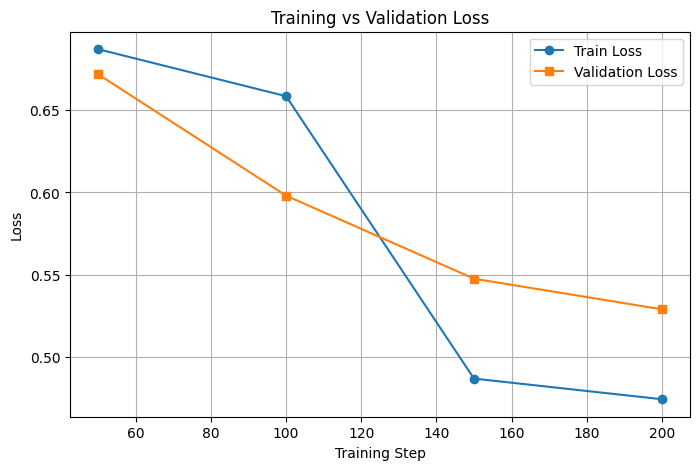

✓ training_curves.png saved.
✓ reproducibility_info.json saved.

Notebook 6 Completed Successfully
Best Model      : /content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/intent_lora_best
Final Model     : /content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/intent_lora
Training Log    : /content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/training_log.csv
Training Curves : /content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/training_curves.png
Reproducibility : /content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/reproducibility_info.json


In [ ]:
# YOUR CODE HERE
# ==========================================================
# 4.2.2 Save Training Outputs
# ==========================================================

import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Save Paths
# ----------------------------------------------------------

OUTPUT_DIR = "/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset"

BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "intent_lora_best")
FINAL_MODEL_PATH = os.path.join(OUTPUT_DIR, "intent_lora")

TRAINING_LOG_PATH = os.path.join(OUTPUT_DIR, "training_log.csv")
CURVE_PATH = os.path.join(OUTPUT_DIR, "training_curves.png")
REPRO_PATH = os.path.join(OUTPUT_DIR, "reproducibility_info.json")

# ----------------------------------------------------------
# Save Final LoRA Checkpoint
# ----------------------------------------------------------

peft_model.save_pretrained(FINAL_MODEL_PATH)

print("✓ Final LoRA checkpoint saved.")

# ----------------------------------------------------------
# Save Training Log
# ----------------------------------------------------------

training_df = pd.DataFrame(training_log)

training_df.to_csv(TRAINING_LOG_PATH, index=False)

print("✓ training_log.csv saved.")

# ----------------------------------------------------------
# Plot Training Curve
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    training_df["step"],
    training_df["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    training_df["step"],
    training_df["val_loss"],
    marker="s",
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.grid(True)
plt.legend()

plt.savefig(CURVE_PATH, dpi=300)

plt.show()

print("✓ training_curves.png saved.")

# ----------------------------------------------------------
# Save Reproducibility Information
# ----------------------------------------------------------

reproducibility = {
    "model_id": MODEL_ID,
    "lora_rank": 16,
    "lora_alpha": 32,
    "target_modules": ["q_proj", "v_proj"],
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "max_steps": MAX_STEPS,
    "validation_every": VAL_EVERY,
    "patience": PATIENCE,
    "best_validation_loss": float(best_val_loss),
    "seed": 42
}

with open(REPRO_PATH, "w") as f:
    json.dump(reproducibility, f, indent=4)

print("✓ reproducibility_info.json saved.")

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print("\n" + "="*60)
print("Notebook 6 Completed Successfully")
print("="*60)

print(f"Best Model      : {BEST_MODEL_PATH}")
print(f"Final Model     : {FINAL_MODEL_PATH}")
print(f"Training Log    : {TRAINING_LOG_PATH}")
print(f"Training Curves : {CURVE_PATH}")
print(f"Reproducibility : {REPRO_PATH}")

---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify before proceeding to Notebook 7.**

- [ ] Tokenized train/valid loaded from disk (`set_format` re-applied)
- [ ] **4.1.1** LoRA configured targeting `q_proj`/`v_proj`
- [ ] **4.1.2** Optimizer + training params + dataloaders set
- [ ] **4.2.1** Training loop run with val monitoring + early stopping + loss curve
- [ ] **4.2.2** Best checkpoint saved + reproducibility info recorded
- [ ] **`./intent_lora_best/` saved** ← _CRITICAL for NB7_
- [ ] **`training_log.csv` + `training_curves.png` saved** ← _Evidence_

**If any item is unchecked, fix it before moving on.**